Loading The Dataset

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("student-por.csv")
print(df.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]


Analysing The Data 

In [35]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nDataset Information:")
print(df.info())

Dataset Shape: (649, 33)

Columns:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  

Checking The Missing Values

In [8]:
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


Checking and removing Duplicate records

In [34]:
print("Duplicate records:", df.duplicated().sum())
df = df.drop_duplicates()
print("New dataset shape:", df.shape)

Duplicate records: 0
New dataset shape: (649, 33)


Selecting G3 as Target Variable

In [11]:
X = df.drop(columns=['G3'])
y = df['G3']

print("Features:")
print(X.columns)
print("\nTarget:")
print(y.name)

Features:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2'],
      dtype='str')

Target:
G3


Converting Categorical into Numerical

In [12]:
X = pd.get_dummies(X, drop_first=True)

print(X.head())
print("Number of features:", X.shape[1])

   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         0       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  ...  guardian_mother  guardian_other  schoolsup_yes  famsup_yes  \
0     1  ...             True           False           True       False   
1     1  ...            False           False          False        True   
2     2  ...             True           False           True       False   
3     1  ...             True           False          False        True   
4     1  ...            False           False          False        True   

   paid_yes  activities_yes  nursery_yes  higher_yes  internet

Spliting The Data into Training and Testing 

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (519, 41)
Testing data: (130, 41)


Creating the ML Model And Training

In [37]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


Making predictions and comparing actual vs predicted

In [38]:
y_pred = model.predict(X_test)

print("Actual values:")
print(y_test.head(10).values)
print("\nPredicted values:")
print(y_pred[:10])

Actual values:
[19 12 18 11 11 17 18  8 10 11]

Predicted values:
[17.23 11.12 17.38 11.09 11.2  16.34 17.47  9.79 10.31 10.47]


Evaluation of Model

In [17]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 0.7460769230769232
Mean Squared Error: 1.5398115384615385
Root Mean Squared Error: 1.2408914289580448
R2 Score: 0.8420984017378219


Plot Actual vs Predicted

In [18]:
result = pd.DataFrame({
    'Actual_G3': y_test.values,
    'Predicted_G3': y_pred
})

print(result.head(20))

    Actual_G3  Predicted_G3
0          19         17.23
1          12         11.12
2          18         17.38
3          11         11.09
4          11         11.20
5          17         16.34
6          18         17.47
7           8          9.79
8          10         10.31
9          11         10.47
10         18         17.83
11         11         12.71
12         12         13.12
13          9         10.38
14         12         11.42
15         14         13.47
16         13         11.52
17          8          8.01
18         15         15.72
19         14         14.88


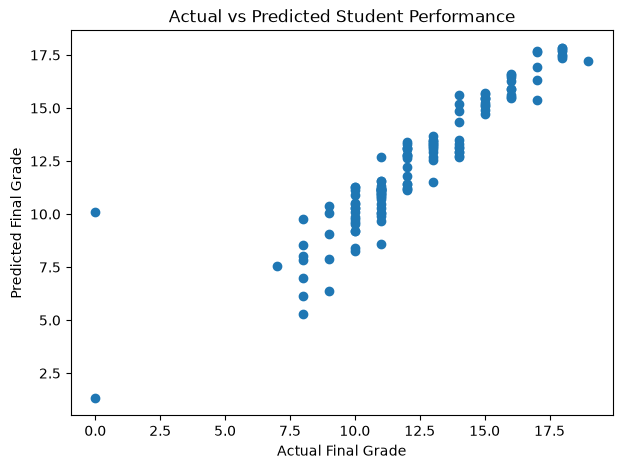

In [39]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Actual vs Predicted Student Performance")
plt.show()

Features Contributed The most

In [20]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(15))

         Feature  Importance
14            G2    0.827115
12      absences    0.035854
13            G1    0.019740
0            age    0.008999
7       freetime    0.008060
9           Dalc    0.007257
1           Medu    0.007206
15     school_MS    0.006518
6         famrel    0.006308
8          goout    0.006013
10          Walc    0.005264
11        health    0.005025
29  reason_other    0.004946
3     traveltime    0.004730
2           Fedu    0.004517


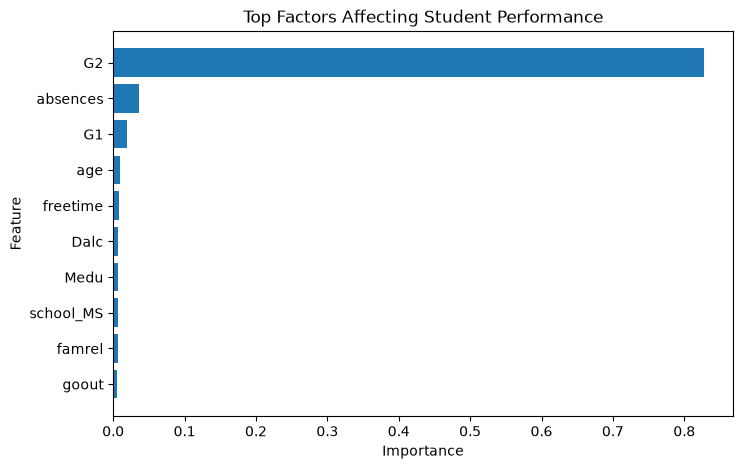

In [21]:
top_features = importance.head(10)
plt.figure(figsize=(8, 5))
plt.barh(
    top_features['Feature'],
    top_features['Importance']
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Factors Affecting Student Performance")
plt.gca().invert_yaxis()
plt.show()

In [41]:
age = int(input("Enter age: "))
studytime = int(input("Enter study time (1-4): "))
failures = int(input("Enter number of previous failures: "))
absences = int(input("Enter number of absences: "))
G1 = float(input("Enter first period grade (G1): "))
G2 = float(input("Enter second period grade (G2): "))

Enter age:  19
Enter study time (1-4):  4
Enter number of previous failures:  0
Enter number of absences:  3
Enter first period grade (G1):  19
Enter second period grade (G2):  19


In [44]:
user_data = pd.DataFrame({
    'age': [age],
    'studytime': [studytime],
    'failures': [failures],
    'absences': [absences],
    'G1': [G1],
    'G2': [G2]
})
for column in X.columns:
    if column not in user_data.columns:
        user_data[column] = 0
user_data = user_data[X.columns]
prediction = model.predict(user_data)
print("Predicted Final Grade (G3):", round(prediction[0], 2))

Predicted Final Grade (G3): 18.16


In [43]:
grade = prediction[0]
if grade < 10:
    performance = "Poor"
elif grade < 14:
    performance = "Average"
elif grade < 17:
    performance = "Good"
else:
    performance = "Excellent"
print("Predicted Final Grade:", round(grade, 2))
print("Performance:", performance)

Predicted Final Grade: 18.16
Performance: Excellent


In [45]:
def predict_student_performance():
    print("Enter Student Details")
    print("----------------------")

    name = input("Student Name: ")
    age = int(input("Age: "))
    studytime = int(input("Study Time (1-4): "))
    failures = int(input("Previous Failures (0-3): "))
    absences = int(input("Absences(Avg of Monthly): "))
    G1 = float(input("First Period Grade (G1 1-20): "))
    G2 = float(input("Second Period Grade (G2 1-20): "))

    user_data = pd.DataFrame({
        'age': [age],
        'studytime': [studytime],
        'failures': [failures],
        'absences': [absences],
        'G1': [G1],
        'G2': [G2]
    })
    for column in X.columns:
        if column not in user_data.columns:
            user_data[column] = 0
    user_data = user_data[X.columns]
    prediction = model.predict(user_data)[0]
    if prediction < 10:
        result = "Fail"
        performance = "Poor"
    else:
        result = "Pass"
        if prediction < 14:
            performance = "Average"
        elif prediction < 17:
            performance = "Good"
        else:
            performance = "Excellent"
    print("\n----------------------")
    print("Student Name:", name)
    print("Predicted Final Grade (G3):", round(prediction, 2))
    print("Result:", result)
    print("Performance:", performance)
    print("----------------------")

In [46]:
predict_student_performance()

Enter Student Details
----------------------


Student Name:  Bunny Alok
Age:  19
Study Time (1-4):  3
Previous Failures (0-3):  1
Absences(Avg of Monthly):  2
First Period Grade (G1 1-20):  10
Second Period Grade (G2 1-20):  8



----------------------
Student Name: Bunny Alok
Predicted Final Grade (G3): 8.46
Result: Fail
Performance: Poor
----------------------
